# Model (Hypothesentests & Muster)

Dieses Notebook beantwortet die Forschungsfragen **RQ2–RQ4** für Projektteil 1 (Mieten NRW).

- **RQ2:** Sind kleinere Wohnungen pro m² teurer als größere Wohnungen?
- **RQ3:** Haben Wohnungsmerkmale (z. B. Balkon, Küche, Baujahr) einen messbaren Einfluss?
- **RQ4:** Lassen sich Mietangebote in NRW in unterschiedliche Muster gruppieren?

> Hinweis: Für RQ4 wird **kein sklearn-KMeans** verwendet, weil auf manchen Windows/Conda-Setups ein `threadpoolctl/OpenBLAS`-Fehler auftreten kann.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, spearmanr


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Daten laden

Wir laden die bereinigte Datei aus der Scrub-Phase: `data/processed/nrw_clean.csv`.


In [2]:
path_clean = Path("../../data/processed/nrw_clean.csv")
df = pd.read_csv(path_clean)

df.shape, df.columns


((62822, 9),
 Index(['regio2', 'baseRent', 'totalRent', 'livingSpace', 'noRooms', 'balcony',
        'hasKitchen', 'yearConstructed', 'price_per_sqm'],
       dtype='object'))

In [3]:
df.isna().sum()


regio2                 0
baseRent               0
totalRent          12091
livingSpace            0
noRooms                0
balcony                0
hasKitchen             0
yearConstructed    12037
price_per_sqm          0
dtype: int64

## RQ2 – Kleine vs. große Wohnungen (Mann-Whitney-U)

**H₀:** Median `price_per_sqm` ist gleich (klein vs. groß).  
**H₁:** Kleine Wohnungen (< 50 m²) sind pro m² teurer als große Wohnungen (> 80 m²).


In [4]:
small = df[df["livingSpace"] < 50].copy()
large = df[df["livingSpace"] > 80].copy()

small["price_per_sqm"].median(), large["price_per_sqm"].median(), len(small), len(large)


(8.2389289392379, 7.960631060935012, 9193, 19805)

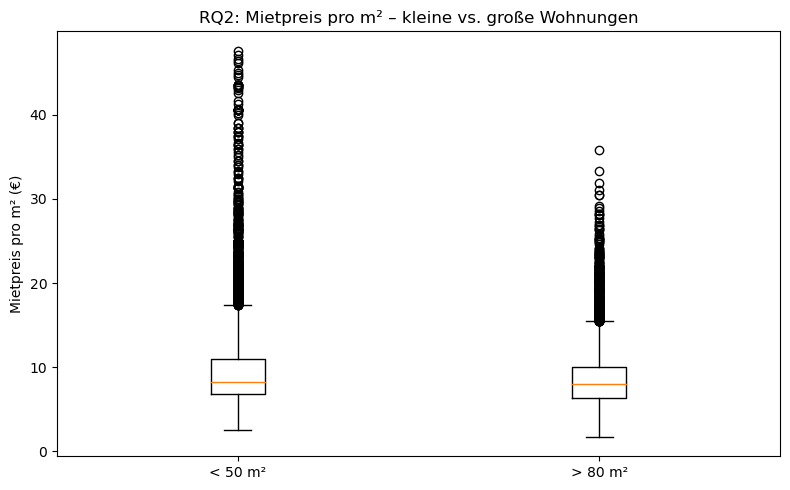

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq2_boxplot_klein_vs_gross.png'))

In [23]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [small["price_per_sqm"], large["price_per_sqm"]],
    labels=["< 50 m²", "> 80 m²"]
)
plt.ylabel("Mietpreis pro m² (€)")
plt.title("RQ2: Mietpreis pro m² – kleine vs. große Wohnungen")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq2_boxplot_klein_vs_gross.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


In [6]:
u_stat, p_value = mannwhitneyu(
    small["price_per_sqm"],
    large["price_per_sqm"],
    alternative="greater"
)
u_stat, p_value


(101956357.5, 3.162664068632506e-61)

In [7]:
if p_value < 0.05:
    print("H₀ wird verworfen: Kleine Wohnungen sind signifikant teurer pro m².")
else:
    print("H₀ kann nicht verworfen werden.")


H₀ wird verworfen: Kleine Wohnungen sind signifikant teurer pro m².


## RQ3 – Einfluss von Merkmalen (Balkon, Küche, Baujahr)

- Balkon: Mann-Whitney-U (H1: mit Balkon teurer)
- Küche: Mann-Whitney-U (H1: mit Küche teurer)
- Baujahr: Spearman-Korrelation (robust bei Nicht-Normalverteilung)


In [8]:
with_balcony = df[df["balcony"] == True]["price_per_sqm"]
without_balcony = df[df["balcony"] == False]["price_per_sqm"]

with_balcony.median(), without_balcony.median(), len(with_balcony), len(without_balcony)


(7.575757575757576, 6.690070422535212, 38504, 24318)

In [9]:
u_stat_balcony, p_balcony = mannwhitneyu(
    with_balcony,
    without_balcony,
    alternative="greater"
)
u_stat_balcony, p_balcony


(561094873.5, 0.0)

In [10]:
if p_balcony < 0.05:
    print("H₀ wird verworfen: Wohnungen mit Balkon sind signifikant teurer pro m².")
else:
    print("H₀ kann nicht verworfen werden.")


H₀ wird verworfen: Wohnungen mit Balkon sind signifikant teurer pro m².


In [11]:
with_kitchen = df[df["hasKitchen"] == True]["price_per_sqm"]
without_kitchen = df[df["hasKitchen"] == False]["price_per_sqm"]

with_kitchen.median(), without_kitchen.median(), len(with_kitchen), len(without_kitchen)


(9.002183211851353, 6.875, 13480, 49342)

In [12]:
u_stat_kitchen, p_kitchen = mannwhitneyu(
    with_kitchen,
    without_kitchen,
    alternative="greater"
)
u_stat_kitchen, p_kitchen


(481650744.5, 0.0)

In [13]:
if p_kitchen < 0.05:
    print("H₀ wird verworfen: Wohnungen mit Einbauküche sind signifikant teurer pro m².")
else:
    print("H₀ kann nicht verworfen werden.")


H₀ wird verworfen: Wohnungen mit Einbauküche sind signifikant teurer pro m².


In [14]:
df_year = df.dropna(subset=["yearConstructed"]).copy()
rho, p_year = spearmanr(df_year["yearConstructed"], df_year["price_per_sqm"])

rho, p_year, df_year.shape


(0.30322604278165116, 0.0, (50785, 9))

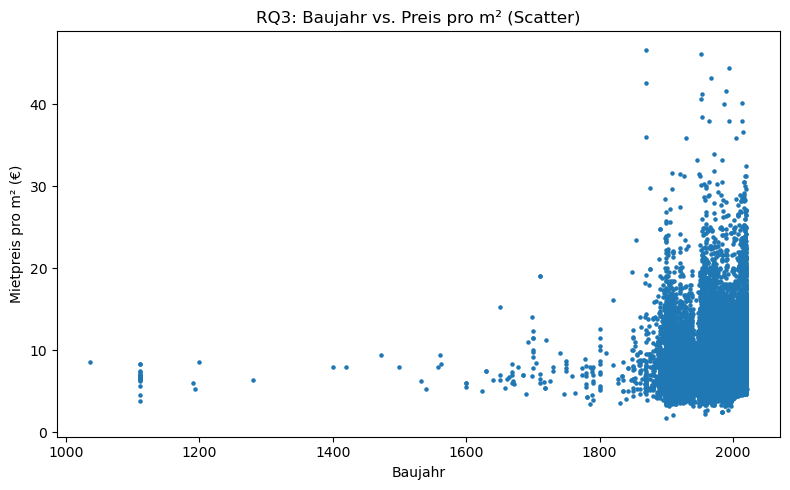

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq3_scatter_baujahr_preis.png'))

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(df_year["yearConstructed"], df_year["price_per_sqm"], s=5)
plt.xlabel("Baujahr")
plt.ylabel("Mietpreis pro m² (€)")
plt.title("RQ3: Baujahr vs. Preis pro m² (Scatter)")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq3_scatter_baujahr_preis.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


## RQ4 – Muster/Cluster in Mietangeboten (NumPy-K-Means)

Wir clustern anhand:
- price_per_sqm
- livingSpace
- noRooms
- yearConstructed (fehlende Werte → Median)

Dann:
1) Standardisieren (Z-Score)
2) K-Means in NumPy
3) Cluster-Profil + Plot


In [16]:
features = df[["price_per_sqm", "livingSpace", "noRooms", "yearConstructed"]].copy()
features["yearConstructed"] = features["yearConstructed"].fillna(features["yearConstructed"].median())

features.shape, features.isna().sum()


((62822, 4),
 price_per_sqm      0
 livingSpace        0
 noRooms            0
 yearConstructed    0
 dtype: int64)

In [17]:
X = features.to_numpy(dtype=float)
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X_scaled = (X - mu) / sigma

X_scaled.shape


(62822, 4)

In [18]:
def kmeans_numpy(X, k=3, n_iter=30, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    centers = X[rng.choice(n, size=k, replace=False)].copy()

    for _ in range(n_iter):
        dists = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = dists.argmin(axis=1)

        new_centers = centers.copy()
        for j in range(k):
            mask = labels == j
            if mask.any():
                new_centers[j] = X[mask].mean(axis=0)

        if np.allclose(new_centers, centers):
            centers = new_centers
            break
        centers = new_centers

    return labels, centers

labels, centers = kmeans_numpy(X_scaled, k=3, n_iter=30, random_state=42)
features["cluster"] = labels

features["cluster"].value_counts()


cluster
1    26709
2    26460
0     9653
Name: count, dtype: int64

In [19]:
cluster_profile = (
    features.groupby("cluster")[["price_per_sqm", "livingSpace", "noRooms", "yearConstructed"]]
    .median()
    .round(2)
)
cluster_profile


,price_per_sqm,livingSpace,noRooms,yearConstructed
cluster,,,,
0,12.40,69.0,2.0,1991.0
1,6.64,60.0,2.0,1957.0
2,7.00,80.0,3.0,1975.0


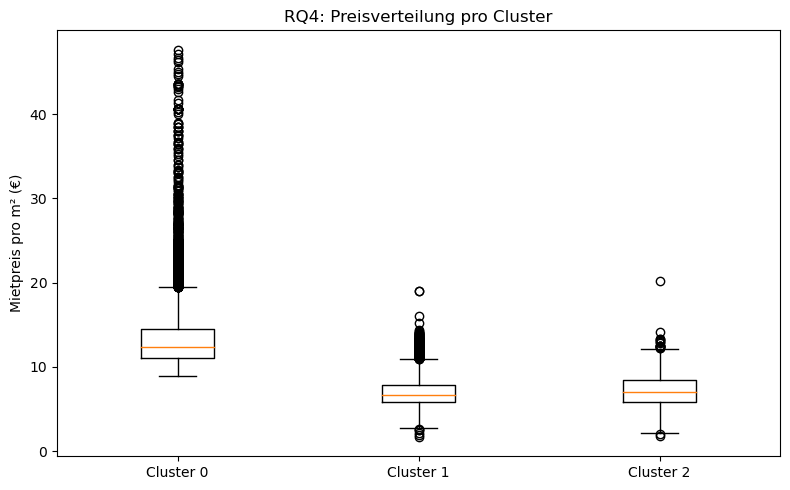

(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/docs/rq4_cluster_preisverteilung.png'))

In [32]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [features.loc[features["cluster"]==c, "price_per_sqm"]
     for c in sorted(features["cluster"].unique())],
    labels=[f"Cluster {c}" for c in sorted(features["cluster"].unique())]
)
plt.ylabel("Mietpreis pro m² (€)")
plt.title("RQ4: Preisverteilung pro Cluster")
plt.tight_layout()

from pathlib import Path
import matplotlib.pyplot as plt

docs_path = Path("../docs")
docs_path.mkdir(parents=True, exist_ok=True)

file_path = docs_path / "rq4_cluster_preisverteilung.png"

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path.exists(), file_path.resolve()


## Export für Projektteil 2: city_price_groups.csv (teuer vs. günstig)

Ziel: Für jede Stadt in NRW wird ein Preisniveau (Median von `price_per_sqm`) berechnet und anschließend in zwei Gruppen eingeteilt:
- `teuer`: Stadt-Median >= Median aller Stadt-Mediane
- `guenstig`: Stadt-Median < Median aller Stadt-Mediane

Diese Datei wird später im Student-Housing-Projekt (RQ-S3) für den Gruppenvergleich genutzt.


In [21]:
import pandas as pd
from pathlib import Path

if "df_nrw_clean" in globals():
    df_base = df_nrw_clean.copy()
elif "df" in globals():
    df_base = df.copy()
else:
    raise NameError("Weder df_nrw_clean noch df ist vorhanden. Lade zuerst nrw_clean.csv in diesem Notebook.")

df_city = (
    df_base.groupby("regio2", as_index=False)["price_per_sqm"]
    .median()
    .rename(columns={"regio2": "city", "price_per_sqm": "median_price_per_sqm"})
)

threshold = df_city["median_price_per_sqm"].median()


df_city["price_group"] = df_city["median_price_per_sqm"].apply(
    lambda x: "teuer" if x >= threshold else "guenstig"
)

out_path = Path("../data/processed/city_price_groups.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df_city.to_csv(out_path, index=False)

out_path.exists(), out_path.resolve(), threshold, df_city["price_group"].value_counts()


(True,
 WindowsPath('C:/Users/User/Desktop/DATA INFORMATION SCIENCE/DIS08/dis08-miete-nrw/data/processed/city_price_groups.csv'),
 7.018334985133796,
 price_group
 teuer       27
 guenstig    27
 Name: count, dtype: int64)